# **CONVOLUTIONAL NEURAL NETWORK - MNIST**

In [1]:
#Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np


In [3]:
# Load and preprocess
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

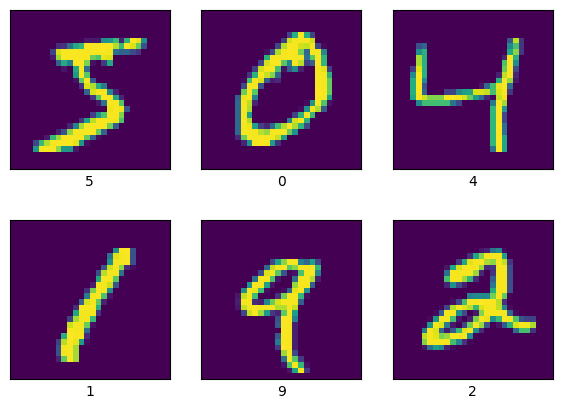

In [6]:
# Visualize some images from the dataset
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
plt.figure(figsize=(7,5))
for i in range(6):
    plt.subplot(2,3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], interpolation='nearest')
    plt.xlabel(class_names[y_train[i].argmax()])
plt.show()

In [7]:
# Build the CNN model
model = models.Sequential([
    # Convolutional layer 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    # Convolutional layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Convolutional layer 3
    layers.Conv2D(64, (3, 3), activation='relu'),
    # Flatten the output
    layers.Flatten(),
    # Fully connected layer
    layers.Dense(64, activation='relu'),
    # Output layer
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Compile the model
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [9]:
# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8648 - loss: 0.4352 - val_accuracy: 0.9851 - val_loss: 0.0445
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9845 - loss: 0.0508 - val_accuracy: 0.9870 - val_loss: 0.0414
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9895 - loss: 0.0335 - val_accuracy: 0.9899 - val_loss: 0.0303
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9919 - loss: 0.0252 - val_accuracy: 0.9856 - val_loss: 0.0458
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9931 - loss: 0.0223 - val_accuracy: 0.9900 - val_loss: 0.0308


In [10]:
# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {accuracy:.2f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9862 - loss: 0.0392
Test accuracy: 0.99


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


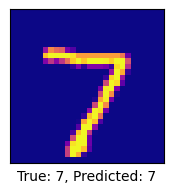

In [12]:
# Predict a single image from the test set
def predict_single_image(index):
    image = x_test[index]
    true_label = np.argmax(y_test[index])
    prediction = model.predict(image.reshape(1, 28, 28, 1))
    predicted_label = np.argmax(prediction)
    plt.figure(figsize=(3,2))
    plt.imshow(image.reshape(28, 28), cmap='plasma')
    plt.xticks([])
    plt.yticks([])
    plt.xlabel(f"True: {class_names[true_label]}, Predicted: {class_names[predicted_label]}")
    plt.show()
predict_single_image(0)